In [181]:
import pandas as pd
import matplotlib.pyplot as plt

In [182]:
df = pd.read_csv("../Data/Global_Supply_Chain_2024to2025.csv")
df["Date"] = pd.to_datetime(df["Date"])

df_clean = df.copy()

In [183]:
# Examine the distribution of shipment lead times.
# The median is also calculated because the distribution contains
# very long shipments that can strongly affect the mean.

df_clean["Lead_Time_Days"].describe()

count    5000.000000
mean       19.355386
std        31.405143
min         0.500000
25%         2.110000
50%         8.245000
75%        21.207500
max       236.390000
Name: Lead_Time_Days, dtype: float64

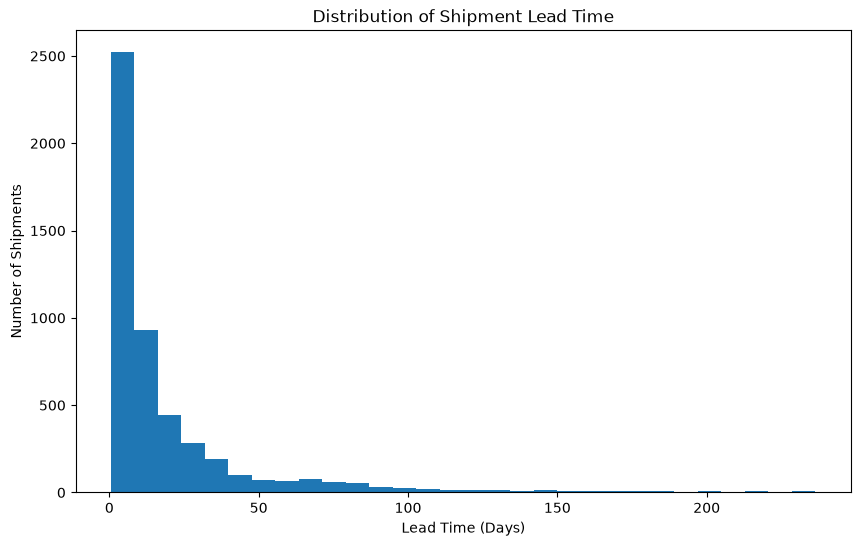

In [184]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["Lead_Time_Days"], bins=30)

plt.title("Distribution of Shipment Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Shipments")

plt.show()

In [185]:
# Compare lead times across transport modes.
# This helps identify whether the choice of transport mode
# is associated with different delivery times.

df_clean.groupby("Transport_Mode")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Transport_Mode,,,,,
Air,1320,1.64,0.93,0.5,8.63
Rail,1185,19.95,11.54,0.5,117.76
Road,1214,16.45,9.30,0.5,102.30
Sea,1281,39.80,21.79,0.5,236.39


In [186]:
df_clean.groupby("Transport_Mode")["Distance_km"].agg(["count", "mean", "median", "max"]).round(2)

,count,mean,median,max
Transport_Mode,,,,
Air,1320,7764.01,7975.64,14993.59
Rail,1185,7810.04,7903.42,14995.91
Road,1214,7593.07,7545.28,14991.50
Sea,1281,7649.46,7533.87,14970.04


In [187]:
# Calculate the correlation between distance and lead time.
# This measures the strength of the linear relationship between
# the two numerical variables.

df_clean[["Distance_km", "Lead_Time_Days"]].corr().round(2)

,Distance_km,Lead_Time_Days
Distance_km,1.00,0.34
Lead_Time_Days,0.34,1.00


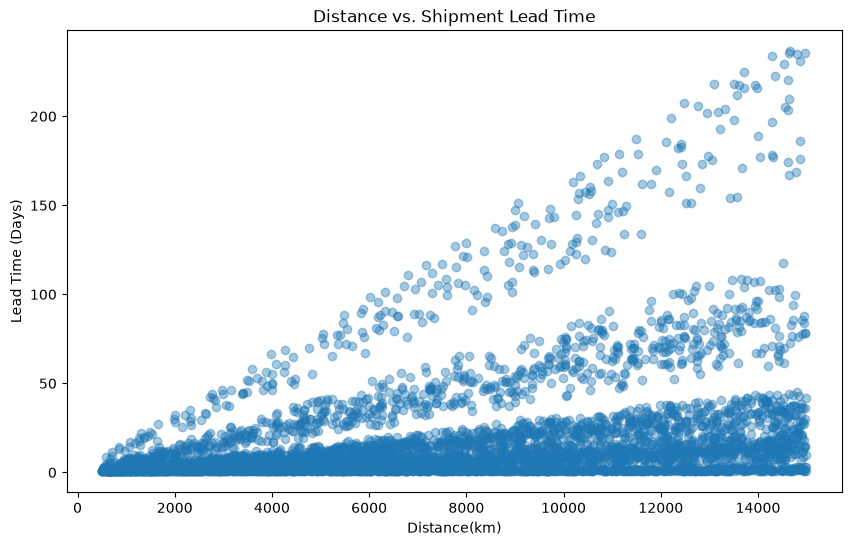

In [188]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["Distance_km"], 
    df_clean["Lead_Time_Days"], 
    alpha=0.4
)

plt.title("Distance vs. Shipment Lead Time")
plt.xlabel("Distance(km)")
plt.ylabel("Lead Time (Days)")
plt.show()

In [189]:
df_clean[[
    "Carrier_Reliability_Score", "Lead_Time_Days"
]].corr().round(2)

,Carrier_Reliability_Score,Lead_Time_Days
Carrier_Reliability_Score,1.00,-0.01
Lead_Time_Days,-0.01,1.00


In [190]:
df_clean.groupby("Transport_Mode")["Disruption_Occurred"].agg(["count", "mean"]).round(3)

,count,mean
Transport_Mode,,
Air,1320,0.617
Rail,1185,0.612
Road,1214,0.610
Sea,1281,0.610


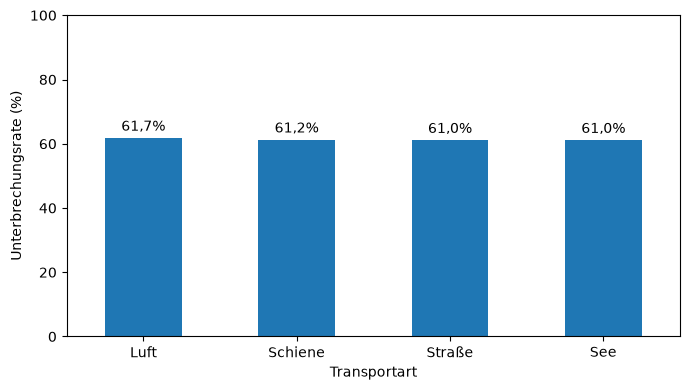

In [191]:
# Unterbrechungsrate nach Transportart

transport_summary = (
    df_clean.groupby("Transport_Mode")["Disruption_Occurred"]
    .agg(["count", "mean"])
    .reset_index()
)

# Unterbrechungsrate in Prozent
transport_summary["Unterbrechungsrate"] = (
    transport_summary["mean"] * 100
)

# Englische Transportarten ins Deutsche übersetzen
transport_labels = {
    "Air": "Luft",
    "Rail": "Schiene",
    "Road": "Straße",
    "Sea": "See"
}

transport_summary["Transportart"] = (
    transport_summary["Transport_Mode"].replace(transport_labels)
)

# Diagramm erstellen
ax = transport_summary.plot(
    x="Transportart",
    y="Unterbrechungsrate",
    kind="bar",
    figsize=(7, 4),
    legend=False,
    title=""
)

ax.set_xlabel("Transportart")
ax.set_ylabel("Unterbrechungsrate (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

# Prozentwerte über den Balken
for container in ax.containers:
    labels = [
        f"{value:.1f}%".replace(".", ",")
        for value in transport_summary["Unterbrechungsrate"]
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

plt.tight_layout()
plt.show()

In [192]:
df_clean.groupby("Weather_Condition")["Disruption_Occurred"].agg(
    ["count", "mean"]
).round(3)

,count,mean
Weather_Condition,,
Clear,995,0.370
Fog,1036,0.481
Hurricane,990,1.000
Rain,977,0.420
Storm,1002,0.795


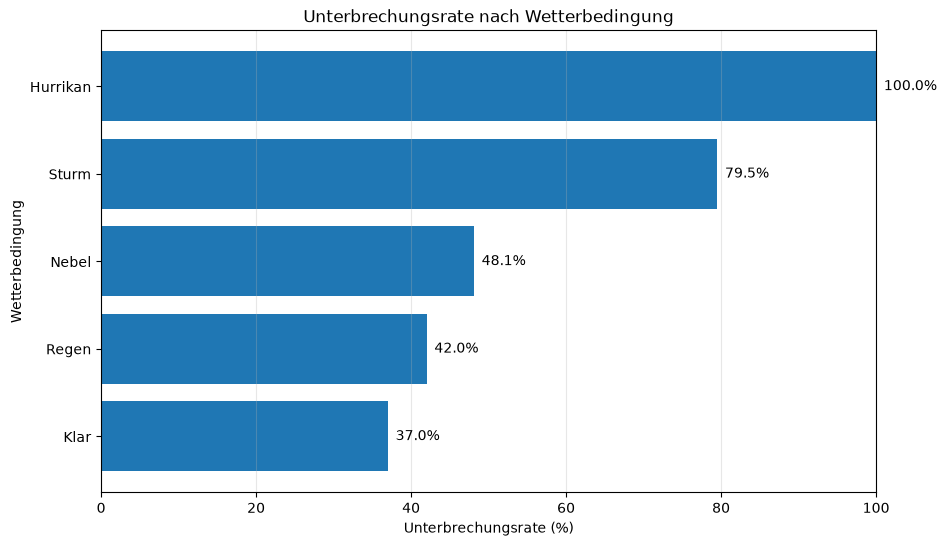

In [193]:
# Unterbrechungsrate nach Wetterbedingung
weather_analysis = (
    df_clean.groupby("Weather_Condition")["Disruption_Occurred"]
    .agg(["count", "mean"])
    .reset_index()
)

weather_analysis["Unterbrechungsrate"] = (
    weather_analysis["mean"] * 100
).round(1)

# Englische Kategorien ins Deutsche übersetzen
weather_analysis["Wetterbedingung"] = weather_analysis["Weather_Condition"].replace({
    "Clear": "Klar",
    "Rain": "Regen",
    "Fog": "Nebel",
    "Storm": "Sturm",
    "Hurricane": "Hurrikan"
})

weather_plot = weather_analysis.sort_values(
    "Unterbrechungsrate",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    weather_plot["Wetterbedingung"],
    weather_plot["Unterbrechungsrate"]
)

ax.set_title("Unterbrechungsrate nach Wetterbedingung")
ax.set_xlabel("Unterbrechungsrate (%)")
ax.set_ylabel("Wetterbedingung")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)

for bar in bars:
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}%",
        va="center"
    )


In [194]:
pd.crosstab(
    df_clean["Transport_Mode"], 
    df_clean["Weather_Condition"], 
    values=df_clean["Disruption_Occurred"], 
    aggfunc="mean"
).round(3)

Weather_Condition,Clear,Fog,Hurricane,Rain,Storm
Transport_Mode,,,,,
Air,0.350,0.500,1.0,0.444,0.789
Rail,0.384,0.457,1.0,0.387,0.821
Road,0.377,0.484,1.0,0.423,0.774
Sea,0.371,0.479,1.0,0.422,0.798


In [195]:
df_clean.groupby("Disruption_Occurred")["Carrier_Reliability_Score"].agg([
    "count", "mean", "median", "min", "max"
]).round(3)

,count,mean,median,min,max
Disruption_Occurred,,,,,
0,1937,0.769,0.781,0.5,1.0
1,3063,0.745,0.741,0.5,1.0


In [196]:
df_clean.groupby("Disruption_Occurred")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Disruption_Occurred,,,,,
0,1937,8.89,6.24,0.5,85.02
1,3063,25.98,10.69,0.5,236.39


In [197]:
df_clean.columns.tolist()

['Shipment_ID',
 'Date',
 'Origin_Port',
 'Destination_Port',
 'Transport_Mode',
 'Product_Category',
 'Distance_km',
 'Weight_MT',
 'Fuel_Price_Index',
 'Geopolitical_Risk_Score',
 'Weather_Condition',
 'Carrier_Reliability_Score',
 'Lead_Time_Days',
 'Disruption_Occurred']

In [198]:
df_clean.groupby("Product_Category")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Product_Category,,,,,
Automotive,959,18.98,7.72,0.5,233.78
Electronics,1016,17.76,8.00,0.5,234.84
Perishables,1009,20.13,8.17,0.5,236.39
Pharmaceuticals,1006,19.80,8.86,0.5,220.25
Textiles,1010,20.10,8.35,0.5,235.41


In [199]:
df_clean.groupby("Product_Category")["Disruption_Occurred"].agg(
    ["count", "mean"]
).round(3)

,count,mean
Product_Category,,
Automotive,959,0.605
Electronics,1016,0.595
Perishables,1009,0.603
Pharmaceuticals,1006,0.611
Textiles,1010,0.649


In [200]:
df_clean[["Fuel_Price_Index", "Lead_Time_Days"]].corr().round(2)

,Fuel_Price_Index,Lead_Time_Days
Fuel_Price_Index,1.00,-0.01
Lead_Time_Days,-0.01,1.00


In [201]:
df_clean.groupby("Disruption_Occurred")["Fuel_Price_Index"].agg(
    ["count", "mean", "median", "min", "max"]
).round(3)

,count,mean,median,min,max
Disruption_Occurred,,,,,
0,1937,2.850,2.84,1.21,4.5
1,3063,2.857,2.83,1.20,4.5


In [202]:
df_clean[["Weight_MT", "Lead_Time_Days"]].corr().round(2)

,Weight_MT,Lead_Time_Days
Weight_MT,1.00,-0.01
Lead_Time_Days,-0.01,1.00


In [203]:
df_clean.groupby("Disruption_Occurred")["Weight_MT"].agg([
    "count", "mean", "median", "min", "max"
]).round(2)

,count,mean,median,min,max
Disruption_Occurred,,,,,
0,1937,243.97,240.25,1.12,499.60
1,3063,247.70,245.40,1.03,499.75


In [204]:
df_clean.groupby("Origin_Port")["Disruption_Occurred"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False).round(3)

,count,mean
Origin_Port,,
Hamburg,597,0.625
Shanghai,644,0.624
Singapore,599,0.623
Antwerp,635,0.614
Dubai,610,0.608
Los Angeles,602,0.603
Busan,667,0.603
Rotterdam,646,0.602


In [205]:
df_clean.groupby("Destination_Port")["Disruption_Occurred"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False).round(3)

,count,mean
Destination_Port,,
Singapore,528,0.633
Marseille,583,0.623
Busan,570,0.621
Shanghai,561,0.619
Antwerp,552,0.614
Hamburg,536,0.610
Rotterdam,574,0.606
Los Angeles,537,0.598
Dubai,559,0.590


In [206]:
monthly_disruption =  (
    df_clean.set_index("Date")
    .resample("ME")["Disruption_Occurred"].agg(["count", "mean"])
)

monthly_disruption.round(3)


,count,mean
Date,,
2024-01-31,173,0.636
2024-02-29,195,0.564
2024-03-31,220,0.568
2024-04-30,229,0.624
2024-05-31,211,0.626
2024-06-30,208,0.678
2024-07-31,174,0.575
2024-08-31,199,0.658
2024-09-30,210,0.614


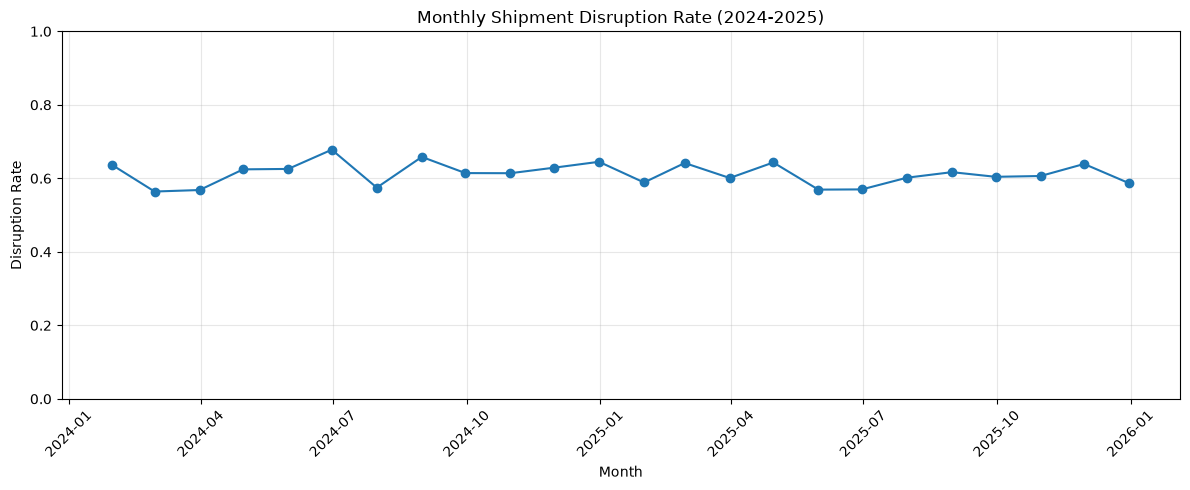

In [207]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_disruption.index,
    monthly_disruption["mean"], 
    marker="o"
)

plt.title("Monthly Shipment Disruption Rate (2024-2025)")
plt.xlabel("Month")
plt.ylabel("Disruption Rate")
plt.ylim(0,1)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [208]:
monthly_lead_time = (
    df_clean.set_index("Date")
    .resample("ME")["Lead_Time_Days"]
    .agg(["count", "mean", "median"])
)

monthly_lead_time.round(2)

,count,mean,median
Date,,,
2024-01-31,173,18.51,8.41
2024-02-29,195,18.19,7.58
2024-03-31,220,20.37,9.80
2024-04-30,229,19.71,8.00
2024-05-31,211,18.34,7.95
2024-06-30,208,21.06,8.56
2024-07-31,174,21.82,9.08
2024-08-31,199,17.48,7.09
2024-09-30,210,16.55,8.56


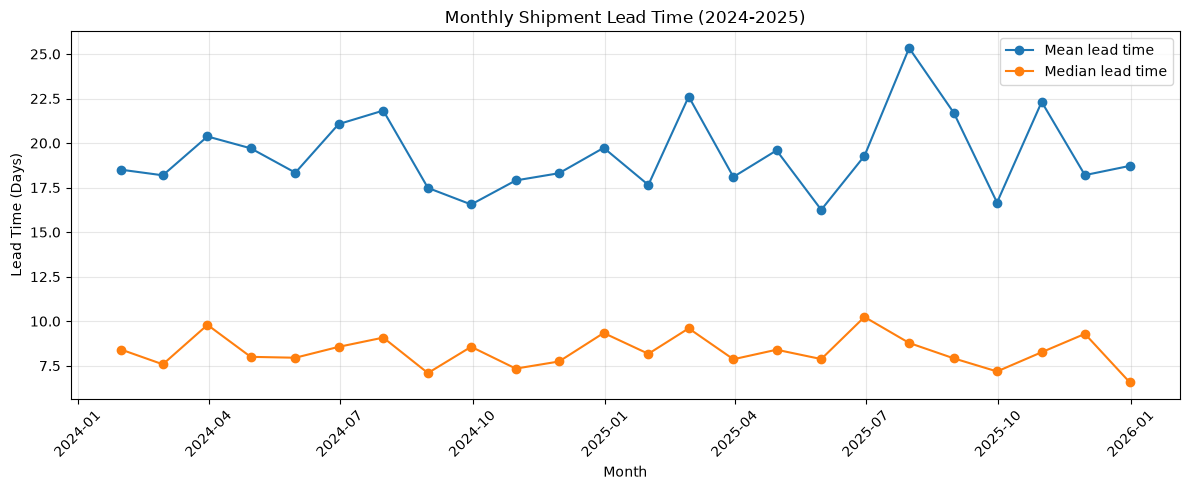

In [209]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_lead_time.index, 
    monthly_lead_time["mean"], 
    marker="o",
    label="Mean lead time"
)

plt.plot(
    monthly_lead_time.index, 
    monthly_lead_time["median"], 
    marker="o", 
    label="Median lead time"

)

plt.title("Monthly Shipment Lead Time (2024-2025)")
plt.xlabel("Month")
plt.ylabel("Lead Time (Days)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [210]:
df_clean.groupby("Weather_Condition")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Weather_Condition,,,,,
Clear,995,6.70,5.13,0.5,30.09
Fog,1036,9.89,7.00,0.5,45.37
Hurricane,990,53.50,40.03,0.5,236.39
Rain,977,7.74,5.98,0.5,34.53
Storm,1002,19.30,14.72,0.5,87.94


<Figure size 1000x600 with 0 Axes>

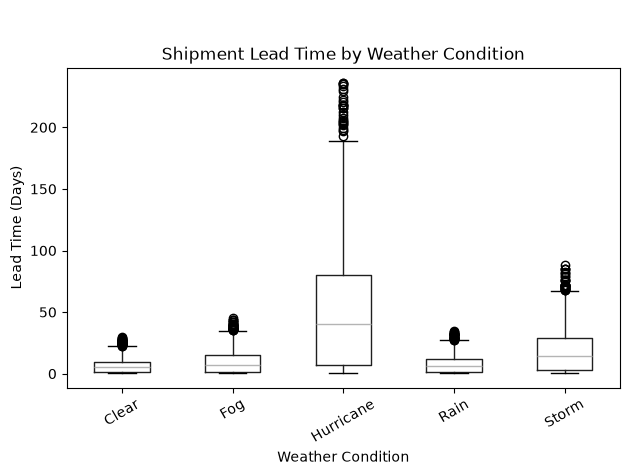

In [211]:
plt.figure(figsize=(10,6))

df_clean.boxplot(
    column="Lead_Time_Days", 
    by="Weather_Condition", 
    grid=False
)

plt.title("Shipment Lead Time by Weather Condition")
plt.suptitle(" ")
plt.xlabel("Weather Condition")
plt.ylabel("Lead Time (Days)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

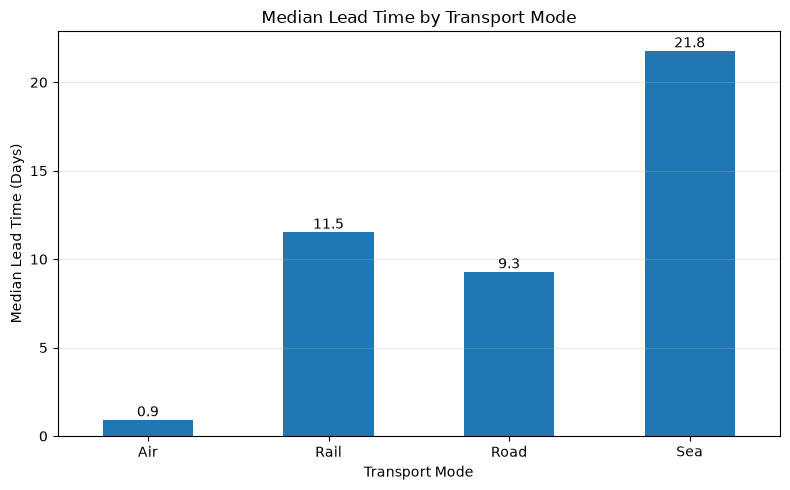

In [212]:
lead_time_by_mode = df.groupby("Transport_Mode")["Lead_Time_Days"].median()

# Show the transport modes in the desired order
lead_time_by_mode = lead_time_by_mode.reindex(["Air", "Rail", "Road", "Sea"])

# Create the chart
ax = lead_time_by_mode.plot(kind="bar", figsize=(8, 5))

plt.title("Median Lead Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Median Lead Time (Days)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

# Add values above the bars
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [213]:
print("Number of unique origin ports:", df["Origin_Port"].nunique())
print("Number of unique destination ports:", df["Destination_Port"].nunique())

print("\nMost common origin ports:")
display(df["Origin_Port"].value_counts().head(10))

print("\nMost common destination ports:")
display(df["Destination_Port"].value_counts().head(10))

print("\nMost common routes:")
display(
    df.groupby(["Origin_Port", "Destination_Port"])
      .size()
      .sort_values(ascending=False)
      .head(15)
      .rename("Shipment_Count")
      .reset_index()
)

Number of unique origin ports: 8
Number of unique destination ports: 9

Most common origin ports:


Origin_Port
Busan          667
Rotterdam      646
Shanghai       644
Antwerp        635
Dubai          610
Los Angeles    602
Singapore      599
Hamburg        597
Name: count, dtype: int64


Most common destination ports:


Destination_Port
Marseille      583
Rotterdam      574
Busan          570
Shanghai       561
Dubai          559
Antwerp        552
Los Angeles    537
Hamburg        536
Singapore      528
Name: count, dtype: int64


Most common routes:


,Origin_Port,Destination_Port,Shipment_Count
0,Antwerp,Busan,101
1,Shanghai,Dubai,98
2,Antwerp,Rotterdam,97
3,Busan,Rotterdam,92
4,Busan,Shanghai,91
5,Busan,Singapore,89
6,Shanghai,Rotterdam,88
7,Busan,Los Angeles,87
8,Shanghai,Busan,87
9,Los Angeles,Busan,87


In [214]:
route_summary = (
    df.groupby(["Origin_Port", "Destination_Port"])
    .agg(
        Shipments=("Disruption_Occurred", "size"),
        Disruptions=("Disruption_Occurred", "sum"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median"),
        Median_Distance=("Distance_km", "median")
    )
    .reset_index()
)

route_summary["Disruption_Rate"] = (
    route_summary["Disruption_Rate"] * 100
).round(1)

route_summary["Median_Lead_Time"] = (
    route_summary["Median_Lead_Time"].round(1)
)

route_summary["Median_Distance"] = (
    route_summary["Median_Distance"].round(0)
)

route_summary = route_summary[
    route_summary["Shipments"] >= 30
].sort_values("Disruption_Rate", ascending=False)

route_summary.head(15)

,Origin_Port,Destination_Port,Shipments,Disruptions,Disruption_Rate,Median_Lead_Time,Median_Distance
45,Rotterdam,Marseille,68,51,75.0,10.3,8722.0
39,Los Angeles,Singapore,68,49,72.1,7.3,5879.0
29,Hamburg,Rotterdam,72,51,70.8,13.8,6708.0
41,Rotterdam,Busan,86,59,68.6,13.1,9220.0
56,Singapore,Antwerp,72,49,68.1,7.4,6818.0
14,Busan,Shanghai,91,62,68.1,11.2,9297.0
12,Busan,Marseille,65,44,67.7,7.8,6627.0
55,Shanghai,Singapore,62,42,67.7,8.5,9549.0
27,Hamburg,Los Angeles,85,57,67.1,9.8,9366.0
6,Antwerp,Shanghai,71,47,66.2,11.3,7901.0


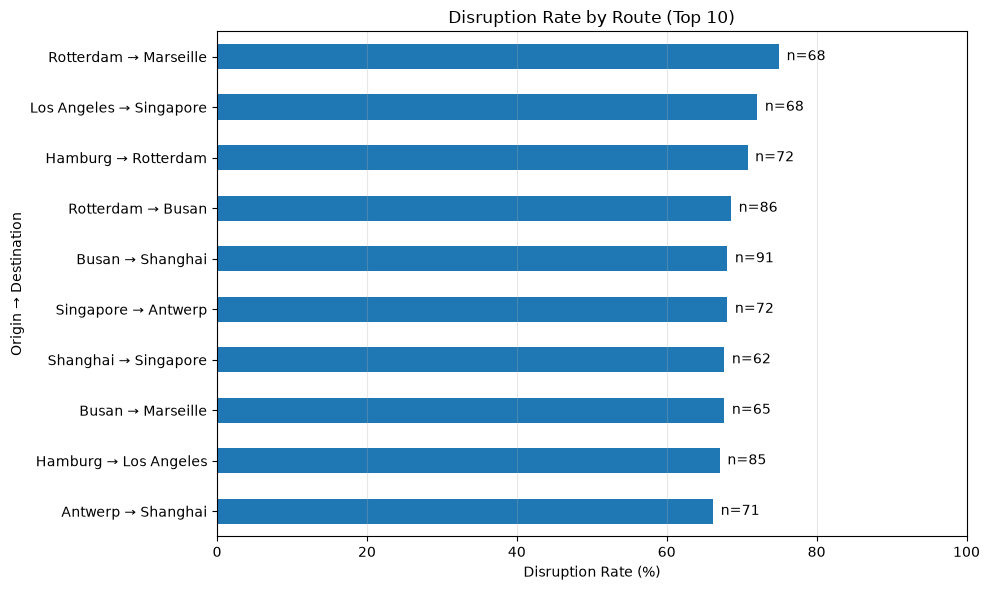

In [215]:
# Select the 10 routes with the highest disruption rates
top_routes = route_summary.head(10).copy()

# Create readable route labels
top_routes["Route"] = (
    top_routes["Origin_Port"] + " → " + top_routes["Destination_Port"]
)

# Plot the disruption rates
ax = top_routes.sort_values("Disruption_Rate").plot(
    x="Route",
    y="Disruption_Rate",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.title("Disruption Rate by Route (Top 10)")
plt.xlabel("Disruption Rate (%)")
plt.ylabel("Origin → Destination")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.3)

# Show shipment counts beside each bar
for bar, count in zip(ax.patches, top_routes.sort_values("Disruption_Rate")["Shipments"]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"n={count}",
        va="center"
    )

plt.tight_layout()
plt.show()


In [216]:
distance_summary = (
    df.assign(
        Distance_Group=pd.qcut(
            df["Distance_km"],
            q=4,
            duplicates="drop"
        )
    )
    .groupby("Distance_Group", observed=True)
    .agg(
        Shipments=("Disruption_Occurred", "size"),
        Disruptions=("Disruption_Occurred", "sum"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Median_Distance_km=("Distance_km", "median"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
)

distance_summary["Disruption_Rate"] = (
    distance_summary["Disruption_Rate"] * 100
).round(1)

distance_summary

,Shipments,Disruptions,Disruption_Rate,Median_Distance_km,Median_Lead_Time
Distance_Group,,,,,
"(500.16900000000004, 4036.01]",1250,755,60.4,2237.300,2.715
"(4036.01, 7750.125]",1250,765,61.2,5876.475,7.355
"(7750.125, 11347.462]",1250,778,62.2,9546.225,11.500
"(11347.462, 14995.91]",1250,765,61.2,13144.270,16.560


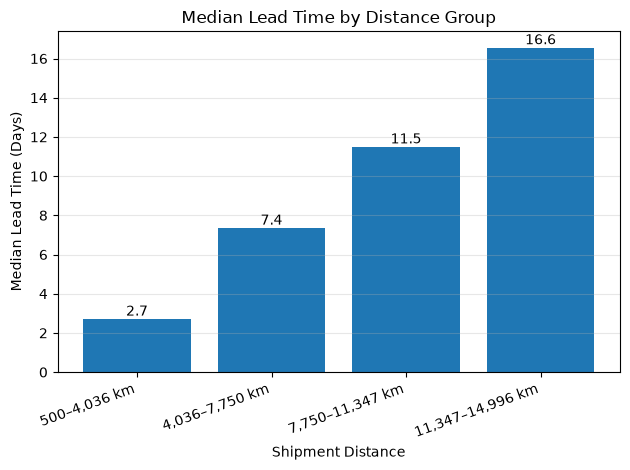

In [217]:
distance_labels = [
    "500–4,036 km",
    "4,036–7,750 km",
    "7,750–11,347 km",
    "11,347–14,996 km"
]

median_lead_times = distance_summary["Median_Lead_Time"].values

ax = plt.bar(distance_labels, median_lead_times)

plt.title("Median Lead Time by Distance Group")
plt.xlabel("Shipment Distance")
plt.ylabel("Median Lead Time (Days)")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar in ax:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [218]:
destination_summary = (
    df.groupby("Destination_Port").agg(
        Shipments=("Disruption_Occurred", "size"),
        Disruptions=("Disruption_Occurred", "sum"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
    .reset_index()

)

destination_summary["Disruption_Rate"] = (
    destination_summary["Disruption_Rate"] * 100
).round(1)

destination_summary["Median_Lead_Time"] = (
    destination_summary["Median_Lead_Time"].round(1)
)

destination_summary.sort_values(
    "Disruption_Rate",
    ascending=False
)

,Destination_Port,Shipments,Disruptions,Disruption_Rate,Median_Lead_Time
8,Singapore,528,334,63.3,8.0
5,Marseille,583,363,62.3,8.9
1,Busan,570,354,62.1,9.1
7,Shanghai,561,347,61.9,8.2
0,Antwerp,552,339,61.4,8.0
3,Hamburg,536,327,61.0,9.1
6,Rotterdam,574,348,60.6,7.2
4,Los Angeles,537,321,59.8,8.0
2,Dubai,559,330,59.0,7.9


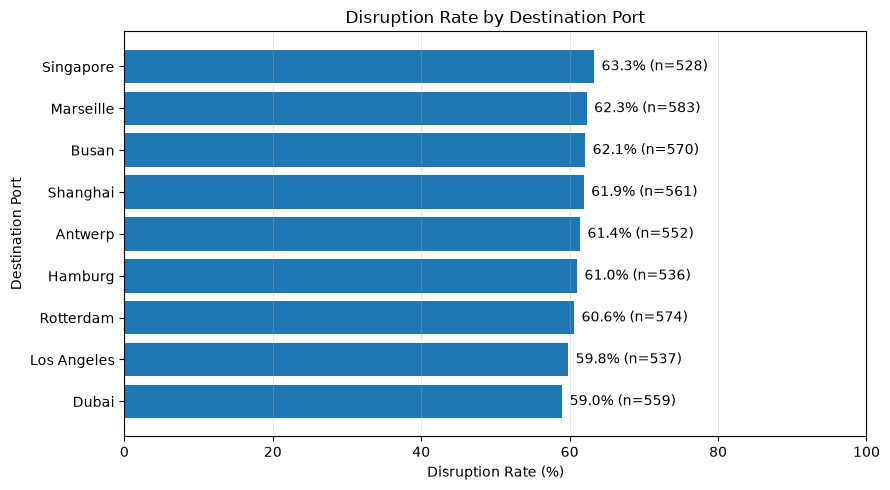

In [219]:


destination_plot = destination_summary.sort_values(
    "Disruption_Rate",
    ascending=True
).copy()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    destination_plot["Destination_Port"],
    destination_plot["Disruption_Rate"]
)

ax.set_title("Disruption Rate by Destination Port")
ax.set_xlabel("Disruption Rate (%)")
ax.set_ylabel("Destination Port")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)

for bar, count in zip(bars, destination_plot["Shipments"]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}% (n={count})",
        va="center"
    )

plt.tight_layout()
plt.show()

In [220]:
# Group shipments into four weight categories
df["Weight_Group"] = pd.qcut(
    df["Weight_MT"],
    q=4,
    labels=["Q1 - Lightest", "Q2", "Q3", "Q4 - Heaviest"],
    duplicates="drop"
)

# Summarize disruption and lead time by weight group
weight_analysis = (
    df.groupby("Weight_Group", observed=True)
    .agg(
        Shipment_Count=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
    .reset_index()
)

weight_analysis["Disruption_Rate"] = (
    weight_analysis["Disruption_Rate"] * 100
).round(2)

weight_analysis["Median_Lead_Time"] = (
    weight_analysis["Median_Lead_Time"].round(2)
)

weight_analysis

,Weight_Group,Shipment_Count,Disruption_Rate,Median_Lead_Time
0,Q1 - Lightest,1250,60.24,8.12
1,Q2,1250,60.96,8.20
2,Q3,1250,62.40,8.18
3,Q4 - Heaviest,1250,61.44,8.40


### Gewicht und Lieferleistung

Die Sendungen wurden anhand ihres Gewichts in vier gleich große Gruppen eingeteilt.

Die Unterbrechungsraten liegen zwischen 60,24 % und 62,40 %. Auch die medianen Lieferzeiten sind mit 8,12 bis 8,40 Tagen sehr ähnlich.

Im Datensatz zeigt sich kein klarer Zusammenhang zwischen dem Gewicht einer Sendung und der Unterbrechungsrate oder der medianen Lieferzeit. Das Gewicht allein scheint die beobachteten Unterschiede in der Lieferleistung daher nur begrenzt zu beschreiben.

Die Ergebnisse sind deskriptiv und zeigen keine Ursache-Wirkungs-Beziehung.

In [221]:
origin_analysis = (
    df.groupby("Origin_Port")
    .agg(
        Shipment_Count=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
    .reset_index()
)

origin_analysis["Disruption_Rate"] = (
    origin_analysis["Disruption_Rate"] * 100
).round(2)

origin_analysis["Median_Lead_Time"] = (
    origin_analysis["Median_Lead_Time"].round(2)
)

origin_analysis.sort_values(
    "Disruption_Rate",
    ascending=False
)

,Origin_Port,Shipment_Count,Disruption_Rate,Median_Lead_Time
3,Hamburg,597,62.48,8.68
6,Shanghai,644,62.42,9.22
7,Singapore,599,62.27,7.88
0,Antwerp,635,61.42,8.31
2,Dubai,610,60.82,8.06
4,Los Angeles,602,60.30,7.38
1,Busan,667,60.27,8.20
5,Rotterdam,646,60.22,8.50


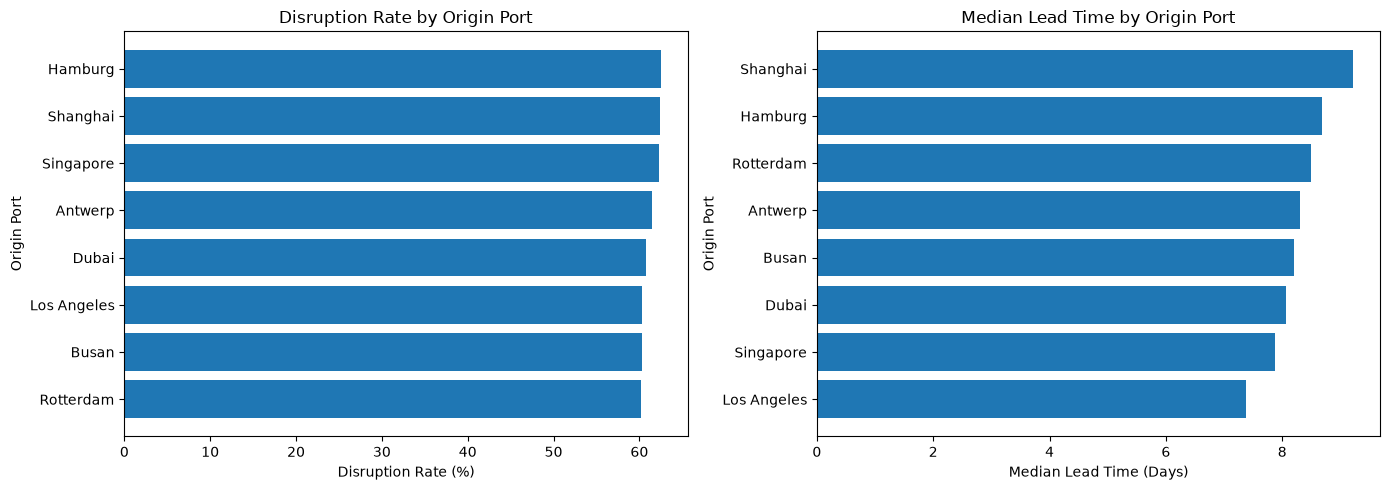

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Disruption rate by origin port
origin_plot = origin_analysis.sort_values("Disruption_Rate")

axes[0].barh(
    origin_plot["Origin_Port"],
    origin_plot["Disruption_Rate"]
)
axes[0].set_title("Disruption Rate by Origin Port")
axes[0].set_xlabel("Disruption Rate (%)")
axes[0].set_ylabel("Origin Port")

# Median lead time by origin port
origin_plot = origin_analysis.sort_values("Median_Lead_Time")

axes[1].barh(
    origin_plot["Origin_Port"],
    origin_plot["Median_Lead_Time"]
)
axes[1].set_title("Median Lead Time by Origin Port")
axes[1].set_xlabel("Median Lead Time (Days)")
axes[1].set_ylabel("Origin Port")

plt.tight_layout()
plt.show()

### Ausgangshafen und Lieferleistung

Die Unterbrechungsraten unterscheiden sich zwischen den acht Ausgangshäfen nur moderat. Sie liegen zwischen 60,22 % in Rotterdam und 62,48 % in Hamburg.

Die mediane Lieferzeit variiert stärker. Sie beträgt 7,38 Tage für Sendungen ab Los Angeles und 9,22 Tage für Sendungen ab Shanghai.

Im Datensatz zeigen sich somit Unterschiede zwischen den Ausgangshäfen, aber keine eindeutigen Hinweise darauf, dass ein bestimmter Hafen grundsätzlich zu mehr Lieferunterbrechungen oder längeren Lieferzeiten führt.

Die Ergebnisse sind deskriptiv und zeigen keine Ursache-Wirkungs-Beziehung.

In [223]:
# Divide shipments into four fuel-price groups
df["Fuel_Price_Group"] = pd.qcut(
    df["Fuel_Price_Index"],
    q=4,
    labels=["Q1 - Lowest", "Q2", "Q3", "Q4 - Highest"]
)

# Compare disruption rates and median lead times
fuel_analysis = (
    df.groupby("Fuel_Price_Group", observed=True)
    .agg(
        Shipment_Count=("Shipment_ID", "count"),
        Disruption_Rate=("Disruption_Occurred", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
    .reset_index()
)

fuel_analysis["Disruption_Rate"] = (
    fuel_analysis["Disruption_Rate"] * 100
).round(2)

fuel_analysis["Median_Lead_Time"] = (
    fuel_analysis["Median_Lead_Time"].round(2)
)

fuel_analysis

,Fuel_Price_Group,Shipment_Count,Disruption_Rate,Median_Lead_Time
0,Q1 - Lowest,1261,61.14,8.19
1,Q2,1245,61.45,8.65
2,Q3,1254,61.56,8.46
3,Q4 - Highest,1240,60.89,7.82


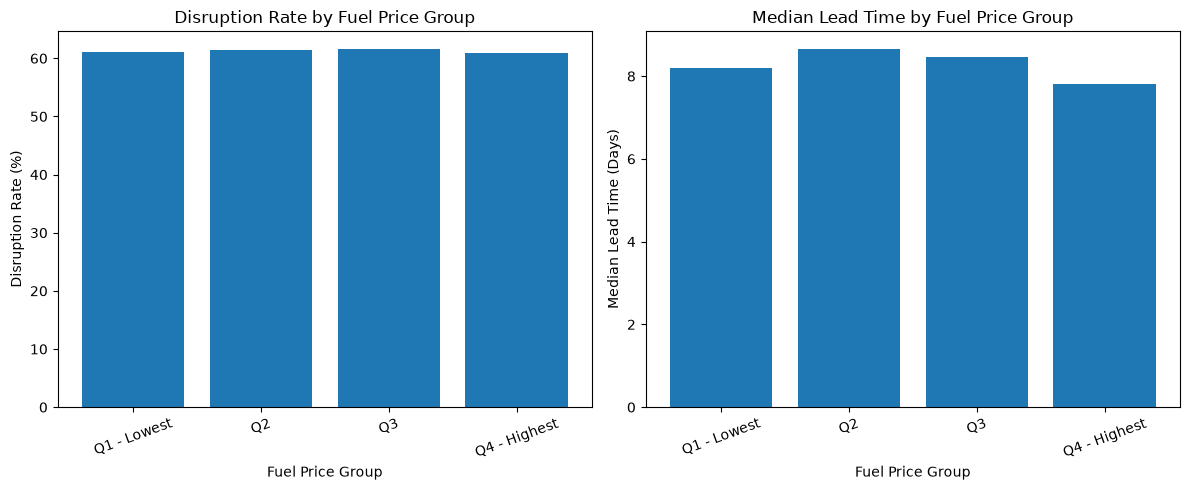

In [224]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Disruption rate by fuel-price group
axes[0].bar(
    fuel_analysis["Fuel_Price_Group"].astype(str),
    fuel_analysis["Disruption_Rate"]
)
axes[0].set_title("Disruption Rate by Fuel Price Group")
axes[0].set_ylabel("Disruption Rate (%)")
axes[0].set_xlabel("Fuel Price Group")
axes[0].tick_params(axis="x", rotation=20)

# Median lead time by fuel-price group
axes[1].bar(
    fuel_analysis["Fuel_Price_Group"].astype(str),
    fuel_analysis["Median_Lead_Time"]
)
axes[1].set_title("Median Lead Time by Fuel Price Group")
axes[1].set_ylabel("Median Lead Time (Days)")
axes[1].set_xlabel("Fuel Price Group")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()